In [75]:
# importing lib
import pandas as pd

In [76]:
import numpy as np

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
# loading datasets
clinical_data = pd.read_csv('Clinical Data_Discovery_Cohort.csv', index_col='PatientID')
clinical_data2 = pd.read_excel('Clinical_Data_Validation_Cohort.xlsx', index_col='Patient ID')

### Data overview

In [79]:
clinical_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 1 to 30
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Specimen date           30 non-null     str  
 1   Dead or Alive           30 non-null     str  
 2   Date of Death           30 non-null     str  
 3   Date of Last Follow Up  30 non-null     str  
 4   sex                     30 non-null     str  
 5   race                    30 non-null     str  
 6   Stage                   30 non-null     str  
 7   Event                   30 non-null     int64
 8   Time                    30 non-null     int64
dtypes: int64(2), str(7)
memory usage: 2.2 KB


In [80]:
# Data cleaning
#standardizing column names
clinical_data = clinical_data.rename(columns={'Time': 'time(days)'})
clinical_data.columns = clinical_data.columns.str.lower().str.replace(" ", "_")

date_cols = ['specimen_date', 'date_of_death', 'date_of_last_follow_up']
clinical_data[date_cols] = clinical_data[date_cols].replace(".", np.nan)

for col in date_cols:
    clinical_data[col] = pd.to_datetime(clinical_data[col],errors="coerce")

# cleaning the stage column    
clinical_data['stage'] = clinical_data['stage'].str.upper().str.replace({'NO': 'N0'})

In [81]:
# standardizing the stage column by removing the prefixes
clinical_data['stage'] = clinical_data['stage'].str.strip()
clinical_data["t_prefix"] = clinical_data["stage"].str.extract(r"^([PCY])")
clinical_data["n_prefix"] = clinical_data["stage"].str.extract(r'([PCY])(?=N)')
clinical_data["stage"] = clinical_data["stage"].str.replace(r'([PCY])(?=[TNM])', '',regex=True)

In [82]:
# checking stage column after cleaning
clinical_data['stage'].unique()

<StringArray>
['T2N2MX', 'T2N1MX', 'T2N0MX',   'T2N0', 'T1N0MX',   'T1N0',   'T2N1',
 'T3N0MX',   'T3N0',   'T4N1']
Length: 10, dtype: str

In [83]:
# key summary statistics
clinical_data.describe()

,specimen_date,date_of_death,date_of_last_follow_up,event,time(days)
count,29,20,29,30.000000,30.000000
mean,2004-12-29 23:10:20.689655,2008-03-14 20:24:00,2009-07-12 11:35:10.344827,0.700000,1637.966667
min,2003-03-17 00:00:00,2004-01-31 00:00:00,2004-01-31 00:00:00,0.000000,35.000000
25%,2004-04-02 00:00:00,2006-03-12 18:00:00,2006-05-09 00:00:00,0.000000,417.250000
50%,2004-09-20 00:00:00,2006-12-30 00:00:00,2008-02-03 00:00:00,1.000000,1133.500000
75%,2005-08-18 00:00:00,2010-04-14 06:00:00,2011-10-12 00:00:00,1.000000,2268.500000
max,2006-08-15 00:00:00,2015-03-13 00:00:00,2020-07-29 00:00:00,1.000000,5900.000000
std,NaN,NaN,NaN,0.466092,1632.854967


### Visual Analysis

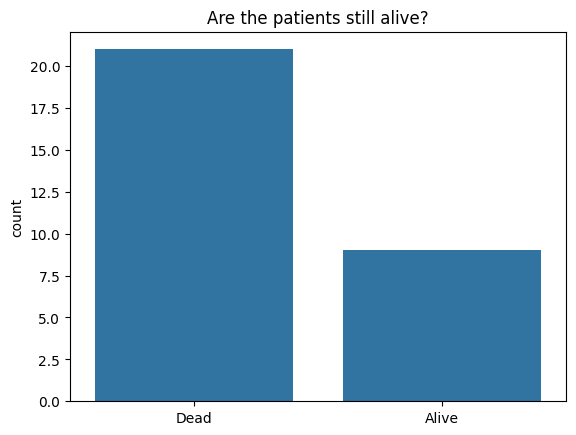

In [84]:
# a count plot displaying the number of people whether dead or alive
sns.countplot(data=clinical_data, x='dead_or_alive')
plt.title('Are the patients still alive?')
plt.xlabel('')
plt.show()

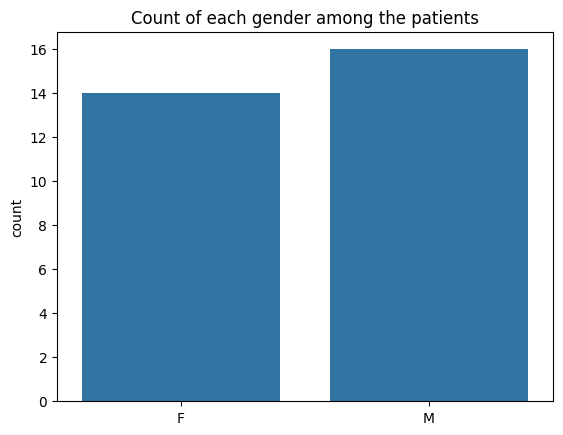

In [85]:
# a count plot displaying the count of each gender among the patients
sns.countplot(data=clinical_data, x='sex')
plt.title('Count of each gender among the patients')
plt.xlabel('')
plt.show()

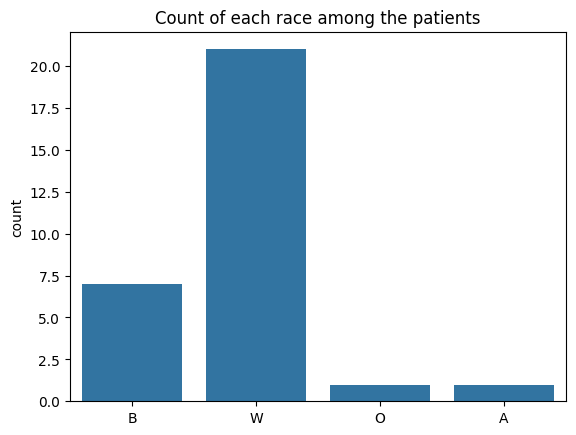

In [86]:
# a count plot displaying the number of each race among the patients
sns.countplot(data=clinical_data, x='race')
plt.title('Count of each race among the patients')
plt.xlabel('')
plt.show()

### Further analysis

In [87]:
# Aggregate clinical data by stage to summarize mean time, cohort size, and event counts
stage_ = clinical_data.groupby('stage')['time(days)'].agg(['mean', 'count'])

In [88]:
stage_event = clinical_data.groupby('stage')['event'].sum()

In [89]:
result = stage_.merge(stage_event, on='stage')
result

,mean,count,event
stage,,,
T1N0,2372.222222,9,7
T1N0MX,756.000000,1,1
T2N0,1809.363636,11,5
T2N0MX,616.500000,2,2
T2N1,191.000000,1,1
T2N1MX,2153.000000,1,1
T2N2MX,1525.000000,2,2
T3N0,201.000000,1,1
T3N0MX,264.000000,1,0


In [90]:
# calc mortality rate (event of death / count of patients) * 100
mortality_rate = (result['event'] / result['count']) * 100 
mortality_rate

stage
T1N0       77.777778
T1N0MX    100.000000
T2N0       45.454545
T2N0MX    100.000000
T2N1      100.000000
T2N1MX    100.000000
T2N2MX    100.000000
T3N0      100.000000
T3N0MX      0.000000
T4N1      100.000000
dtype: float64

In [91]:
# Aggregate clinical data by sex to summarize mean time, cohort size, and event counts
result1 = clinical_data.groupby('sex').agg(mean_time=('time(days)', 'mean'), count_=('time(days)', 'count'), event_sum=('event', 'sum'))
result1

,mean_time,count_,event_sum
sex,,,
F,2146.357143,14,9
M,1193.125000,16,12


In [92]:
# Aggregate clinical data by race to summarize mean time, cohort size, and event counts
result2 = clinical_data.groupby('race').agg(mean_time=('time(days)', 'mean'), count_=('time(days)', 'count'), event_sum=('event', 'sum'))
result2

,mean_time,count_,event_sum
race,,,
A,2307.000000,1,1
B,2872.571429,7,5
O,45.000000,1,1
W,1270.428571,21,14


### Validation Cohort Data overview

In [93]:
clinical_data2.info()

<class 'pandas.DataFrame'>
Index: 95 entries, P109342 to P138014
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Survival time (days)        95 non-null     int64  
 1   Event (death: 1, alive: 0)  95 non-null     int64  
 2   Tumor size (cm)             95 non-null     float64
 3   Grade                       95 non-null     int64  
 4   Stage (TNM 8th edition)     95 non-null     str    
 5   Age                         95 non-null     int64  
 6   Sex                         95 non-null     str    
 7   Cigarette                   95 non-null     str    
 8   Pack per year               95 non-null     float64
 9   Type.Adjuvant               22 non-null     str    
 10  batch                       95 non-null     int64  
 11  EGFR                        86 non-null     str    
 12  KRAS                        65 non-null     str    
dtypes: float64(2), int64(5), str(6)
memory usa

In [94]:
# Data cleaning
# standardizing column names
clinical_data2.columns = clinical_data2.columns.str.lower().str.replace(' ', '_')

### Visual analysis

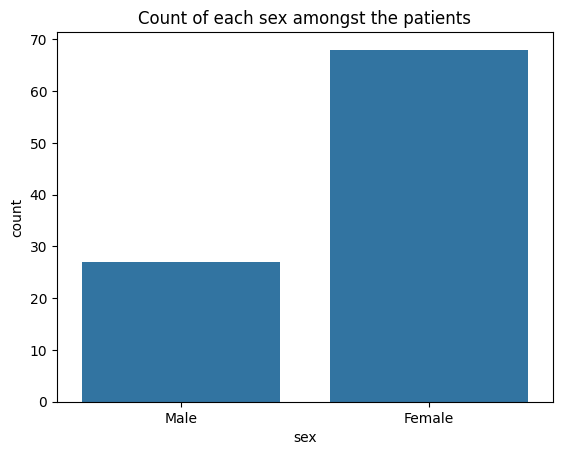

In [95]:
# plotting the count of each sex
sns.countplot(data=clinical_data2, x='sex')
plt.title('Count of each sex amongst the patients')
plt.show()

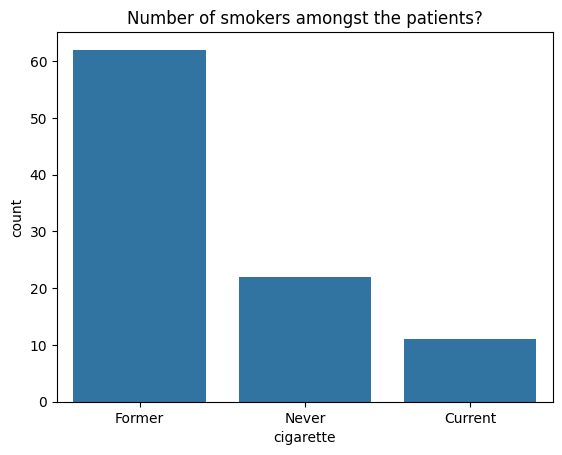

In [96]:
# plotting the count of smokers
sns.countplot(data=clinical_data2, x='cigarette')
plt.title('Number of smokers amongst the patients?')
plt.show()

In [97]:
egfr_count = clinical_data2['egfr'].value_counts()

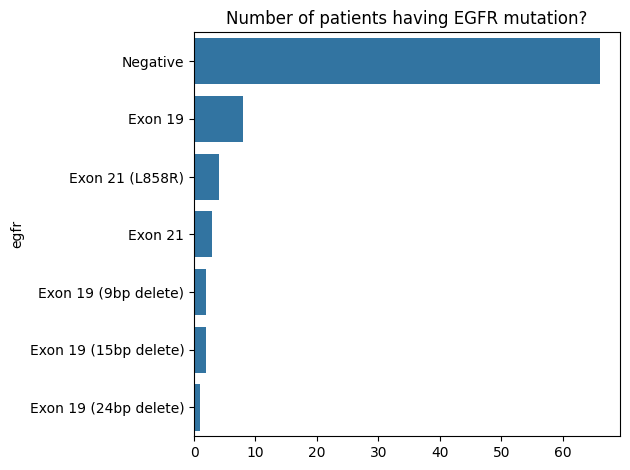

In [98]:
# plotting the count of patients with egfr mutation
sns.barplot(x=egfr_count.values, y=egfr_count.index)
plt.title('Number of patients having EGFR mutation?')
plt.tight_layout()
plt.show()

In [99]:
kras_count = clinical_data2['kras'].value_counts()

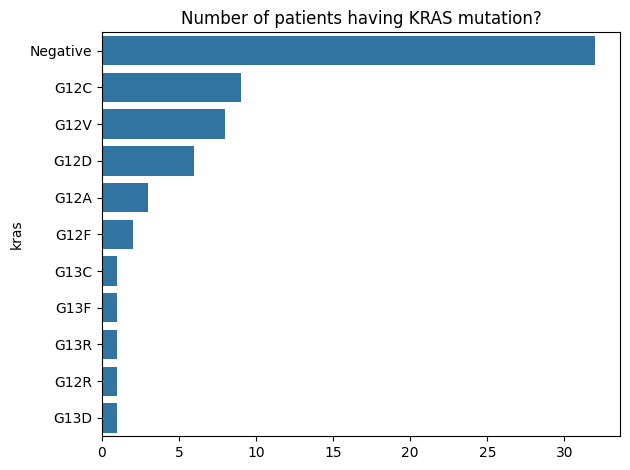

In [100]:
# plotting the count of patients with KRAS mutation
sns.barplot(x=kras_count.values, y=kras_count.index)
plt.title('Number of patients having KRAS mutation?')
plt.tight_layout()
plt.show()

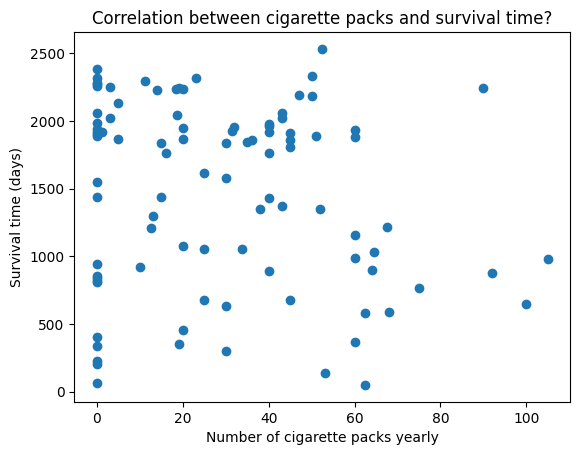

In [101]:
# plotting a scatter plot between number of cigarette packs and survival time
plt.scatter(x=clinical_data2['pack_per_year'], y=clinical_data2['survival_time_(days)'])
plt.title('Correlation between cigarette packs and survival time?')
plt.xlabel('Number of cigarette packs yearly')
plt.ylabel('Survival time (days)')
plt.show()

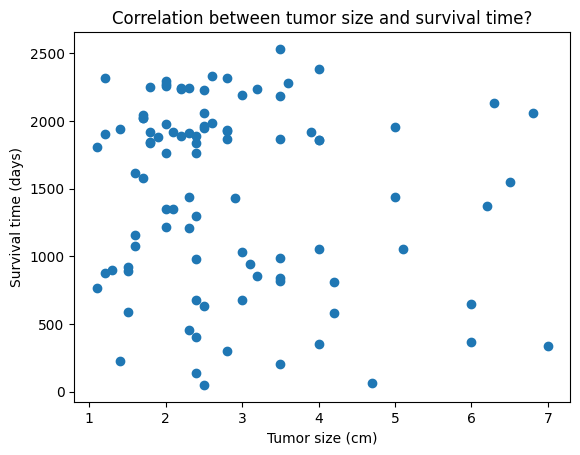

In [102]:
# plotting a scatter plot between number of cigarette packs and survival time
plt.scatter(x=clinical_data2['tumor_size_(cm)'], y=clinical_data2['survival_time_(days)'])
plt.title('Correlation between tumor size and survival time?')
plt.xlabel('Tumor size (cm)')
plt.ylabel('Survival time (days)')
plt.show()

In [103]:
# checking unique values in stage column
clinical_data2['stage_(tnm_8th_edition)'].unique()

<StringArray>
['IB', 'IA2', 'IA3', 'IIIA', 'IIA', 'Recurrence', 'IIB', 'IVA', 'IIIB']
Length: 9, dtype: str

### Further Analysis

In [104]:
# key summary statistics
clinical_data2.describe()

,survival_time_(days),"event_(death:_1,_alive:_0)",tumor_size_(cm),grade,age,pack_per_year,batch
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,1471.515789,0.410526,2.854737,2.368421,66.589474,29.253684,2.431579
std,681.642133,0.494539,1.365281,0.602347,9.698097,26.205783,0.807579
min,50.000000,0.000000,1.100000,1.000000,48.000000,0.000000,1.000000
25%,898.500000,0.000000,2.000000,2.000000,60.000000,2.125000,2.000000
50%,1760.000000,0.000000,2.400000,2.000000,67.000000,25.000000,3.000000
75%,1981.000000,1.000000,3.500000,3.000000,72.500000,45.000000,3.000000
max,2532.000000,1.000000,7.000000,3.000000,88.000000,105.000000,3.000000


In [ ]:
# Aggregate clinical data by sex to summarize mean time, count, and event counts
result3 = clinical_data2.groupby('sex').agg(mean_time=('survival_time_(days)', 'mean'), count_=('survival_time_(days)', 'count'), event_sum=('event_(death:_1,_alive:_0)', 'sum'))
result3

,mean_time,count_,event_sum
sex,,,
Female,1451.705882,68,25
Male,1521.407407,27,14


In [106]:
# Aggregate clinical data by stage to summarize mean time, max and min number of survival time
clinical_data2.groupby('stage_(tnm_8th_edition)')['survival_time_(days)'].agg(['mean', 'max', 'min'])

,mean,max,min
stage_(tnm_8th_edition),,,
IA2,1623.800000,2314,228
IA3,1554.650000,2318,135
IB,1731.285714,2532,208
IIA,1267.500000,1956,579
IIB,1160.416667,2059,66
IIIA,1160.923077,2387,50
IIIB,858.333333,1054,647
IVA,1300.000000,1300,1300
Recurrence,1480.333333,1927,592


In [107]:
# Aggregate clinical data, summarizing the sum of death events occuring by stage
clinical_data2.groupby('stage_(tnm_8th_edition)')['event_(death:_1,_alive:_0)'].sum().sort_values(ascending=False)

stage_(tnm_8th_edition)
IIIA          9
IA2           8
IB            6
IIB           5
IA3           4
IIIB          3
Recurrence    2
IIA           1
IVA           1
Name: event_(death:_1,_alive:_0), dtype: int64

In [108]:
# Aggregate clinical data, summarizing the sum of death events occuring by grade
clinical_data2.groupby('grade')['event_(death:_1,_alive:_0)'].sum().sort_values(ascending=False)

grade
3    22
2    15
1     2
Name: event_(death:_1,_alive:_0), dtype: int64